Found: 25000 cats, 25000 dogs
(400, 224, 224, 3)


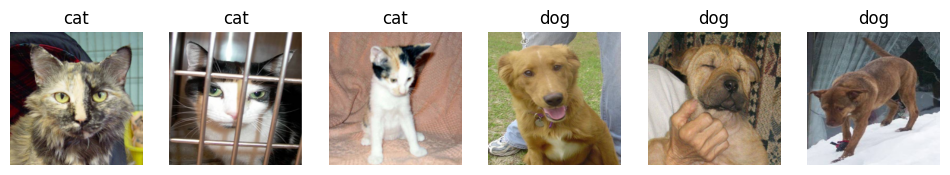

2026-09-21 05:31:34.568389: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(400, 2048)
0    211
1    189
Name: count, dtype: int64
true     cat  dog
cluster          
0         13  198
1        187    2
Cluster mapping: {0: 'dog', 1: 'cat'}
Accuracy: 96.25%


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

DATA_DIR = "/kaggle/input"
IMG_SIZE = (224, 224)   # ResNet50 input size
SAMPLE_SIZE = 200       # per class
EXTS = (".jpg", ".jpeg", ".png")

# Find images
cat_paths, dog_paths = [], []
for root, dirs, files in os.walk(DATA_DIR):
    for f in files:
        if not f.lower().endswith(EXTS):
            continue
        full = os.path.join(root, f)
        key = (os.path.basename(root) + "/" + f).lower()
        if "cat" in key and "dog" not in key:
            cat_paths.append(full)
        elif "dog" in key and "cat" not in key:
            dog_paths.append(full)

print("Found:", len(cat_paths), "cats,", len(dog_paths), "dogs")
assert cat_paths and dog_paths, "No images found. Check DATA_DIR."

def load_images(paths, label, n):
    data, labels = [], []
    for p in sorted(paths)[:n]:
        try:
            img = Image.open(p).convert("RGB").resize(IMG_SIZE)
        except Exception:
            continue
        data.append(np.array(img))
        labels.append(label)
    return data, labels

cat_imgs, cat_labels = load_images(cat_paths, "cat", SAMPLE_SIZE)
dog_imgs, dog_labels = load_images(dog_paths, "dog", SAMPLE_SIZE)

images = np.array(cat_imgs + dog_imgs)
true_labels = np.array(cat_labels + dog_labels)
print(images.shape)

# VISUALIZATION (true labels, before training)
fig, axes = plt.subplots(1, 6, figsize=(12, 2))
idxs = np.linspace(0, len(images) - 1, 6, dtype=int)
for ax, idx in zip(axes, idxs):
    ax.imshow(images[idx])
    ax.set_title(true_labels[idx])
    ax.axis("off")
plt.show()

# FEATURE EXTRACTION (pretrained ResNet50, no classifier head)
model = ResNet50(weights="imagenet", include_top=False, pooling="avg")
X = model.predict(preprocess_input(images.astype("float32")), batch_size=32, verbose=0)
print(X.shape)  # (400, 2048)

# TRAINING
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X)

# TESTING
predicted_clusters = kmeans.predict(X)
print(pd.Series(predicted_clusters).value_counts())

# VALIDATION
print(pd.crosstab(predicted_clusters, true_labels,
                  rownames=["cluster"], colnames=["true"]))

# ACCURACY
pred_a = np.where(predicted_clusters == 0, "cat", "dog")
pred_b = np.where(predicted_clusters == 0, "dog", "cat")
acc_a = (pred_a == true_labels).mean()
acc_b = (pred_b == true_labels).mean()

if acc_a >= acc_b:
    accuracy, mapping = acc_a, {0: "cat", 1: "dog"}
else:
    accuracy, mapping = acc_b, {0: "dog", 1: "cat"}

print(f"Cluster mapping: {mapping}")
print(f"Accuracy: {accuracy * 100:.2f}%")